# Looking behind occlusions: amodal segmentation for on-tree apple fruit sizing — hands-on demo

Reproduction of the inference pipeline from:

> Gené-Mola, J., Ferrer-Ferrer, M., Gregorio, E., Blok, P.M., Hemming, J., Morros, J.-R., Rosell-Polo, J.R., Vilaplana, V., Ruiz-Hidalgo, J. (2023).
> **Looking behind occlusions: A study on amodal segmentation for robust on-tree apple fruit size estimation.**
> *Computers and Electronics in Agriculture*, 209, 107854. https://doi.org/10.1016/j.compag.2023.107854 (open access, CC BY 4.0)

**Links**
- Paper (full text): https://repositori.udl.cat/bitstreams/252d6028-a28c-4576-9011-5758427ebff6/download
- Author code (pinned commit `628ddbf`, Apache-2.0): https://github.com/GRAP-UdL-AT/Amodal_Fruit_Sizing
- Pretrained weights (Zenodo, `model_0002999.pth`, 877 MB): https://zenodo.org/record/7144328/files/model_0002999.pth
- Training dataset (Zenodo, CC BY 4.0, 13.5 GB — **not** downloaded here): https://zenodo.org/record/7260694

**What this notebook does (scope)**
1. Builds the authors' vendored detectron2 fork (ORCNN with parallel modal + amodal mask heads).
2. Downloads the authors' released pretrained model (ResNeXt-101 32x8d FPN backbone, 1 apple class).
3. Runs inference + millimetre diameter estimation on the **2 demo RGB-D images shipped in the repository**
   (`demo/demo_data/`), using the authors' diameter code (`utils/utils_diameter.py`) unchanged.
4. Visualizes modal/amodal masks, reports per-apple diameter (mm), occlusion % and confidence, exports CSV.

**What this notebook does NOT do**: training, dataset-level benchmarks (paper: F1 = 0.86, MAE = 4.5 mm),
or the Elstar case study. The 2 demo images have no ground-truth annotations, so results are qualitative;
this demo does not verify the paper's dataset-level metrics.

**日本語説明**: このノートブックは、モーダル(可視部)＋アモーダル( occlusion を含む完全形)	instance セグメンテ
ーション ORCNN と、ピンホールカメラモデルによるりんご直径(mm)推定を、著者公開の学習済みモデルとデモ画像
2 枚で再現します。学習や論文のデータセット全体のベンチマーク再計算は対象外です。


## 0. Runtime selection and how to run

- **Both CPU (standard) and GPU (T4) runtimes work**: the notebook detects the available device
  and the C++ extension build auto-detects CUDA (on GPU runtimes the CUDA kernels of the fork are
  compiled too, so setup takes a few minutes longer there).
- Recommended: **Runtime → Change runtime type → CPU (standard) or T4 GPU**, then **Runtime → Run all**.
- Measured on a CPU runtime (2026-09-27): clone + detectron2 build ≈ 2.5 min, weights download
  (877 MB) ≈ 44 s, inference (2 images) ≈ 27 s, **total ≈ 4.5 min**; downloads ≈ 0.95 GB.
  GPU-runtime timings are reported in the validation record at the end (build ≈ 4.9 min, total ≈ 6.3 min).
- Limitations: the legacy detectron2 fork (2022, torch 1.12 era) is built from source against the
  Colab-preinstalled PyTorch with small behavior-preserving patches; if the maintainers change
  Colab's stack, this cell may need adjusting (see the final section).

**日本語**: CPU(標準)でも GPU(T4)でも動作します(デバイスと CUDA の有無は自動検出)。
「ランタイム → ランタイムのタイプを変更」で CPU または T4 GPU を選び、「ランタイム → すべてのセルを
実行」してください。重み 877 MB を含め総ダウンロード約 0.95 GB、CPU で合計約 4.5 分でした。
GPU ではセットアップに数分追加されます(最終セクションに実測値)。


## 1. Environment check

Prints the Python / PyTorch / NumPy versions and CPU resources actually used by this run,
so the environment of the validation run is visible from the notebook itself.

**日本語**: 実行環境(Python / PyTorch / NumPy のバージョンと CPU 資源)を確認します。

In [ ]:
import os, platform, multiprocessing
import torch, numpy

print("python      :", platform.python_version())
print("torch       :", torch.__version__)
print("numpy       :", numpy.__version__)
print("CPU cores   :", multiprocessing.cpu_count())
mem_kb = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
print("RAM (GiB)   : %.1f" % (mem_kb / 2**30))


python      : 3.13.15
torch       : 2.11.0+cpu
numpy       : 2.1.3
CPU cores   : 2
RAM (GiB)   : 12.7


## 2. Get the authors' code (pinned commit) and build their detectron2 fork

Clones `GRAP-UdL-AT/Amodal_Fruit_Sizing` at the pinned commit `628ddbf` and compiles its vendored
detectron2 fork (originally sizecnn → ORCNN → detectron2), which contains the ORCNN modal/amodal
ROI heads used by the paper (`detectron2/modeling/roi_heads/mask_amodal_head.py`,
`mask_visible_head.py`). Two Colab-compatibility steps, both behavior-preserving API adaptations
(no numerical change):
1. The extension is built with `python setup.py build_ext --inplace` and the repo is put on
   `sys.path`, because on 2025+ pip the legacy `pip install -e .` path re-invokes pip in an
   isolated build env without torch and fails (observed in validation).
2. Seven `AT_DISPATCH_*` calls in `detectron2/layers/csrc/` pass `.type()` (removed API); they are
   replaced by `.scalar_type()` — the same ScalarType argument, matching the upstream detectron2 fix —
   and `PIL.Image.LINEAR` (removed Pillow alias) becomes `PIL.Image.BILINEAR` (identical filter).
   The CUDA sources additionally need the THC include replaced by `ATEN/cuda/Atomic.cuh`
   (THC was removed in torch 1.11; upstream detectron2 made the same change).
3. The fork's runtime dependencies (`fvcore`, `iopath`, `omegaconf`) are installed explicitly, since
   the in-place build does not run `install_requires` and they are absent from the current Colab image.
Observed build time on a 2-core CPU runtime: ~25 minutes (estimate for other runs).

**日本語**: 著者のリポジトリを固定コミット `628ddbf` でクローンし、同梱の detectron2 フォークの
C++ 拡張をソースからビルドします。新しい Colab の pip では `pip install -e .` が失敗するため
`setup.py build_ext --inplace` を使用し、torch 2.x で削除された `.type()` API を同一動作の
`.scalar_type()` に置き換える互換パッチ(5 箇所)を適用します。ビルドに 20〜30 分かかります。

In [ ]:
%%bash
set -e
REPO_COMMIT=628ddbf33841adabf261dc8616e30662d729ff8d
if [ ! -d /content/Amodal_Fruit_Sizing ]; then
  git clone -q https://github.com/GRAP-UdL-AT/Amodal_Fruit_Sizing /content/Amodal_Fruit_Sizing
fi
cd /content/Amodal_Fruit_Sizing
git checkout -q $REPO_COMMIT
echo "checked out: $(git rev-parse HEAD)"

# Colab/torch-2.x compatibility patch: .type() -> .scalar_type() inside AT_DISPATCH macros only
# (upstream detectron2 made the same change; identical ScalarType is passed, no numerical change)
sed -i 's/input\.type(), "ROIAlign_forward"/input.scalar_type(), "ROIAlign_forward"/' detectron2/layers/csrc/ROIAlign/ROIAlign_cpu.cpp
sed -i 's/grad\.type(), "ROIAlign_forward"/grad.scalar_type(), "ROIAlign_forward"/' detectron2/layers/csrc/ROIAlign/ROIAlign_cpu.cpp
sed -i 's/input\.type(), "ROIAlignRotated_forward"/input.scalar_type(), "ROIAlignRotated_forward"/' detectron2/layers/csrc/ROIAlignRotated/ROIAlignRotated_cpu.cpp
sed -i 's/grad\.type(), "ROIAlignRotated_forward"/grad.scalar_type(), "ROIAlignRotated_forward"/' detectron2/layers/csrc/ROIAlignRotated/ROIAlignRotated_cpu.cpp
sed -i 's/dets\.type(), "nms_rotated"/dets.scalar_type(), "nms_rotated"/' detectron2/layers/csrc/nms_rotated/nms_rotated_cpu.cpp
sed -i 's/Image\.LINEAR/Image.BILINEAR/' detectron2/data/transforms/transform.py
# CUDA sources (compiled only on GPU runtimes; identical argument value, upstream-style fixes)
sed -i 's/dets_sorted\.type(), "nms_rotated_kernel_cuda"/dets_sorted.scalar_type(), "nms_rotated_kernel_cuda"/' detectron2/layers/csrc/nms_rotated/nms_rotated_cuda.cu
sed -i 's/\.type(), "deformable_im2col_gpu"/.scalar_type(), "deformable_im2col_gpu"/' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
sed -i 's/\.type(), "deformable_col2im_gpu"/.scalar_type(), "deformable_col2im_gpu"/' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
sed -i 's/\.type(), "deformable_col2im_coord_gpu"/.scalar_type(), "deformable_col2im_coord_gpu"/' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
sed -i 's/\.type(), "modulated_deformable_im2col_gpu"/.scalar_type(), "modulated_deformable_im2col_gpu"/' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
sed -i 's/\.type(), "modulated_deformable_col2im_gpu"/.scalar_type(), "modulated_deformable_col2im_gpu"/' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
sed -i 's/\.type(), "modulated_deformable_col2im_coord_gpu"/.scalar_type(), "modulated_deformable_col2im_coord_gpu"/' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
sed -i 's|#include <THC/THCAtomics.cuh>|#include <ATen/cuda/Atomic.cuh>|' detectron2/layers/csrc/deformable/deform_conv_cuda_kernel.cu
echo "compatibility patch applied"

# runtime dependencies of the fork (not preinstalled on current Colab; not installed by build_ext)
pip install -q fvcore iopath omegaconf || { echo 'pip dependency install FAILED'; exit 1; }

# compile the C++ extension for this interpreter unless an importable build already exists
python -c "import detectron2._C" 2>/dev/null || {
  python setup.py build_ext --inplace > /content/detectron2_build.log 2>&1 || {
    echo 'BUILD FAILED — last lines of /content/detectron2_build.log:'; tail -30 /content/detectron2_build.log; exit 1; }
}
python -c "import detectron2._C" && echo "compiled _C extension importable"
ls -la detectron2/_C*.so


checked out: 628ddbf33841adabf261dc8616e30662d729ff8d
compatibility patch applied
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 8.8 MB/s eta 0:00:00
compiled _C extension importable
-rwxr-xr-x 1 root root 16681784 Sep 27 00:14 detectron2/_C.cpython-313-x86_64-linux-gnu.so
-rw-r--r-- 1 root root 14214288 Sep 27 00:11 detectron2/_C.cpython-36m-x86_64-linux-gnu.so
-rw-r--r-- 1 root root 13745520 Sep 27 00:11 detectron2/_C.cpython-38-x86_64-linux-gnu.so


If the build succeeded, the fork imports and the authors' diameter utilities are reachable:

**日本語**: ビルドが成功していれば detectron2 フォークと著者の直径計算ユーティリティを読み込めます。

In [ ]:
import sys
sys.path.insert(0, '/content/Amodal_Fruit_Sizing')  # make the built fork importable
import detectron2
from detectron2.engine import DefaultPredictor       # pulls in the compiled _C ops
from utils import utils_diameter                     # authors' diameter math (used verbatim below)
print("detectron2 fork + compiled ops imported OK, version:", detectron2.__version__)


detectron2 fork + compiled ops imported OK, version: 0.1


## 3. Download the released pretrained model

- File: `model_0002999.pth` (877,207,503 bytes; the iteration-3000 checkpoint selected by validation
  loss in the paper, Sec. 2.2).
- Source: Zenodo record [7144328](https://zenodo.org/record/7144328/files/model_0002999.pth),
  linked from the repository README ("Pretrained weights" table).
- Integrity: MD5 `dd1266cd0477092a1aad106aeec893c0` (from the Zenodo API metadata) is verified after
  download. Code license: Apache-2.0; dataset/weights record: CC BY 4.0.

**日本語**: README に記載の学習済みモデル(Zenodo, 877 MB)をダウンロードし、MD5 を検証します。

In [ ]:
import hashlib, urllib.request, os

WEIGHTS_URL = 'https://zenodo.org/record/7144328/files/model_0002999.pth'
WEIGHTS_MD5 = 'dd1266cd0477092a1aad106aeec893c0'
WEIGHTS_PATH = '/content/model_0002999.pth'

def md5_of(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

if not os.path.exists(WEIGHTS_PATH):
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)  # ~877 MB
size = os.path.getsize(WEIGHTS_PATH)
got = md5_of(WEIGHTS_PATH)
print(f"size: {size} bytes (expected 877207503)")
print(f"md5 : {got}")
assert got == WEIGHTS_MD5, "MD5 mismatch — re-download the weights"
print("weights verified OK")


size: 877207503 bytes (expected 877207503)
md5 : dd1266cd0477092a1aad106aeec893c0
weights verified OK


## 4. Load and preview the demo RGB-D inputs

The repository ships 2 demo images under `demo/demo_data/` (RGB image + photogrammetric depth map
`.npy` + `focal_length.txt` with f = 5805.34 px for both images). Depth values are in metres
(the diameter formula multiplies by 1000 to get mm, see next sections). We print the actual
image/depth shapes and depth range rather than assuming them.

**日本語**: リポジトリ同梱のデモ画像 2 枚(RGB + 深度マップ + 焦点距離 5805.34 px)を読み込み、
形状と深度の範囲を確認して表示します。

focal lengths (px): {'_MG_2669_18.png': 5805.34, '_MG_2743_14.png': 5805.34}
_MG_2669_18.png: image (1300, 1300, 3), depth (1300, 1300) float64, valid depth 2.60-3.76 m
_MG_2743_14.png: image (1300, 1300, 3), depth (1300, 1300) float64, valid depth 2.46-16.35 m


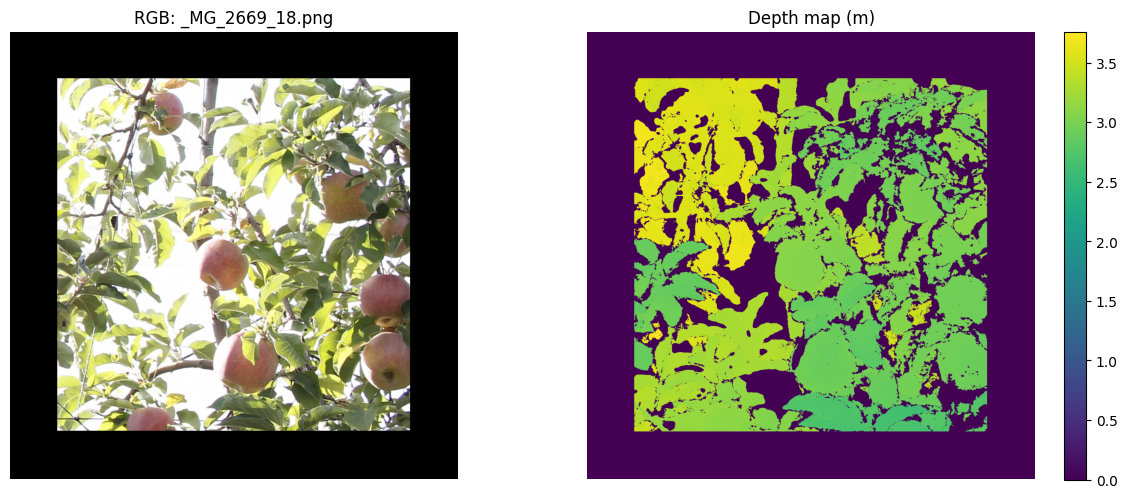

In [ ]:
import csv, os
import cv2, numpy as np
import matplotlib.pyplot as plt

DEMO_DIR = '/content/Amodal_Fruit_Sizing/demo/demo_data'
DEMO_IMAGES = ['_MG_2669_18.png', '_MG_2743_14.png']

# focal length in pixels, as provided by the authors
focal_length = {}
with open(os.path.join(DEMO_DIR, 'focal_length.txt')) as f:
    for row in csv.reader(f):
        focal_length[row[0]] = float(row[1])
print("focal lengths (px):", focal_length)

rgb, depth = {}, {}
for name in DEMO_IMAGES:
    rgb[name] = cv2.imread(os.path.join(DEMO_DIR, 'images', name))          # BGR, uint8
    depth[name] = np.load(os.path.join(DEMO_DIR, 'depth_maps', name[:-4] + '.npy'))
    assert rgb[name].shape[:2] == depth[name].shape[:2], f"RGB/depth size mismatch for {name}"
    d = depth[name][depth[name] > 0]
    print(f"{name}: image {rgb[name].shape}, depth {depth[name].shape} {depth[name].dtype}, "
          f"valid depth {d.min():.2f}-{d.max():.2f} m")

# side-by-side preview: RGB and depth for the first demo image
name = DEMO_IMAGES[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(rgb[name], cv2.COLOR_BGR2RGB)); axes[0].set_title(f"RGB: {name}")
im = axes[1].imshow(depth[name], cmap='viridis')
axes[1].set_title("Depth map (m)"); plt.colorbar(im, ax=axes[1], fraction=0.04)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()


## 5. Build the ORCNN predictor exactly as the authors' inference script

Mirrors `AmodalFruitSize_inference.py` lines 60–71: config
`COCO-InstanceSegmentation/mask_orcnn_X_101_32x8d_FPN_3x.yaml` (ResNeXt-101 32x8d + FPN backbone,
the config matching the released weights — the paper text says "ResNet-101" but the README weights
table and inference script use this X-101 config), 1 class (apple), test score threshold 0.2 and
NMS threshold 0.1. Threshold choices: the authors' repository demo passes `--conf 0` (raw output,
mostly low-score detections) while the paper's measurement protocol states "A minimum confidence of
0.2 was set" (Sec. 3.1); we follow the paper's 0.2 so the table shows the apples the paper would
measure. One necessary runtime adaptation: this 2022 fork defaults to `cfg.MODEL.DEVICE = "cuda"`;
we select cuda/cpu according to availability so the notebook also runs on the CPU runtime.

**日本語**: 著者の推論スクリプトと同じ設定(ORCNN X-101-32x8d FPN, クラス数 1, スコア閾値 0,
NMS 0.1)で予測器を構築します。論文本文は ResNet-101 と書かれていますが、公開重みに対応する設定は
ResNeXt-101(X-101)です。2022 年のフォークはデバイス既定が cuda のため、利用可能な
デバイスに合わせて設定します。

In [ ]:
import torch
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor

cfg = get_cfg()
cfg.merge_from_file('/content/Amodal_Fruit_Sizing/configs/COCO-InstanceSegmentation/'
                    'mask_orcnn_X_101_32x8d_FPN_3x.yaml')
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1            # single class: apple
cfg.MODEL.WEIGHTS = WEIGHTS_PATH
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.2    # paper Sec 3.1: minimum confidence 0.2
cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = 0.1      # authors' demo uses --nms_thr 0.1
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # fork defaults to cuda
cfg.DATASETS.TEST = ("AmodalFruitSize_test",)  # authors' script line 69; metadata is auto-created empty

predictor = DefaultPredictor(cfg)              # loads the checkpoint (may take ~1 min on first load)
print("predictor ready on", cfg.MODEL.DEVICE, ":", cfg.MODEL.WEIGHTS)


predictor ready on cpu : /content/model_0002999.pth


## 6. Inference + millimetre diameter estimation (the paper's core method)

For each detected apple (paper Sec. 2.3, Eqs. 1–6; code `utils/utils_diameter.py`):
- **Depth** `z` = mean depth over the *modal* (visible) mask pixels with 2σ outlier removal, Eq. (1).
- **Pixel diameter** `d` = 2·√A from the *amodal* mask area A, Eq. (2).
- **Millimetre diameter** `D = d·z/f` (pinhole model, Eq. 6), with f = 5805.34 px and z in metres → D in mm.
- **Occlusion** = 1 − (visible area)/(amodal area); visibility % = 100 − occlusion %.
- Detection confidence comes from the CNN. In the paper, filtering to visibility > 60% improved
  MAE from 4.5 mm to 2.93 mm — we apply the same 60% filter as a demo below.

The authors' function `amodal_diameter_estimation` is called **unchanged**.

**日本語**: モーダルマスクから深度 z(Eq.1)、アモーダルマスク面積から画素直径 d(Eq.2)、
ピンホールモデルで mm 直径 D = d·z/f(Eq.6)を計算します。著者のコードをそのまま呼び出します。

In [ ]:
import pandas as pd
import torch

results = []  # one row per detected apple
overlays = {}  # name -> dict with prediction tensors for visualization

for name in DEMO_IMAGES:
    img = rgb[name]
    outputs = predictor(img)                                   # BGR input, as in the authors' script
    preds = outputs["instances"].to("cpu")
    assert hasattr(preds, "pred_visible_masks"), (
        "the ORCNN fork did not produce pred_visible_masks — check the build")
    diameters, occlusions = utils_diameter.amodal_diameter_estimation(
        depth[name], preds, focal_length[name])                # authors' code, verbatim
    scores = preds.scores.tolist()
    overlays[name] = {"preds": preds}

    for j in range(len(preds)):
        results.append({
            "image": name,
            "apple_id": j,
            "diameter_mm": float(diameters[j]),
            "visibility_pct": 100.0 * (1.0 - occlusions[j]),
            "score": float(scores[j]),
        })

df = pd.DataFrame(results).sort_values(["image", "score"], ascending=[True, False])
print(f"total detections: {len(df)}")
df.round(2)


/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


total detections: 14


,image,apple_id,diameter_mm,visibility_pct,score
0,_MG_2669_18.png,0,84.68,84.74,1.00
1,_MG_2669_18.png,1,93.39,74.99,1.00
2,_MG_2669_18.png,2,79.55,94.83,1.00
3,_MG_2669_18.png,3,79.31,48.12,1.00
4,_MG_2669_18.png,4,71.87,48.50,1.00
5,_MG_2669_18.png,5,79.41,86.70,1.00
6,_MG_2669_18.png,6,84.04,66.31,1.00
7,_MG_2669_18.png,7,73.55,30.29,0.98
8,_MG_2743_14.png,0,92.13,90.49,1.00
9,_MG_2743_14.png,1,75.87,62.90,1.00


## 7. Visualization: input, modal (cyan) / amodal (orange) contours, depth

Amodal masks (orange) extend behind occlusions where the modal masks (cyan) stop.
The diameter above is computed from the **orange** amodal area and the depth under the **cyan**
visible region.

**日本語**: 水色がモーダル(可視部)、オレンジがアモーダル(occlusion を含む完全形)の輪郭です。
直径はオレンジ領域の面積と、水色領域下の深度から求めます。

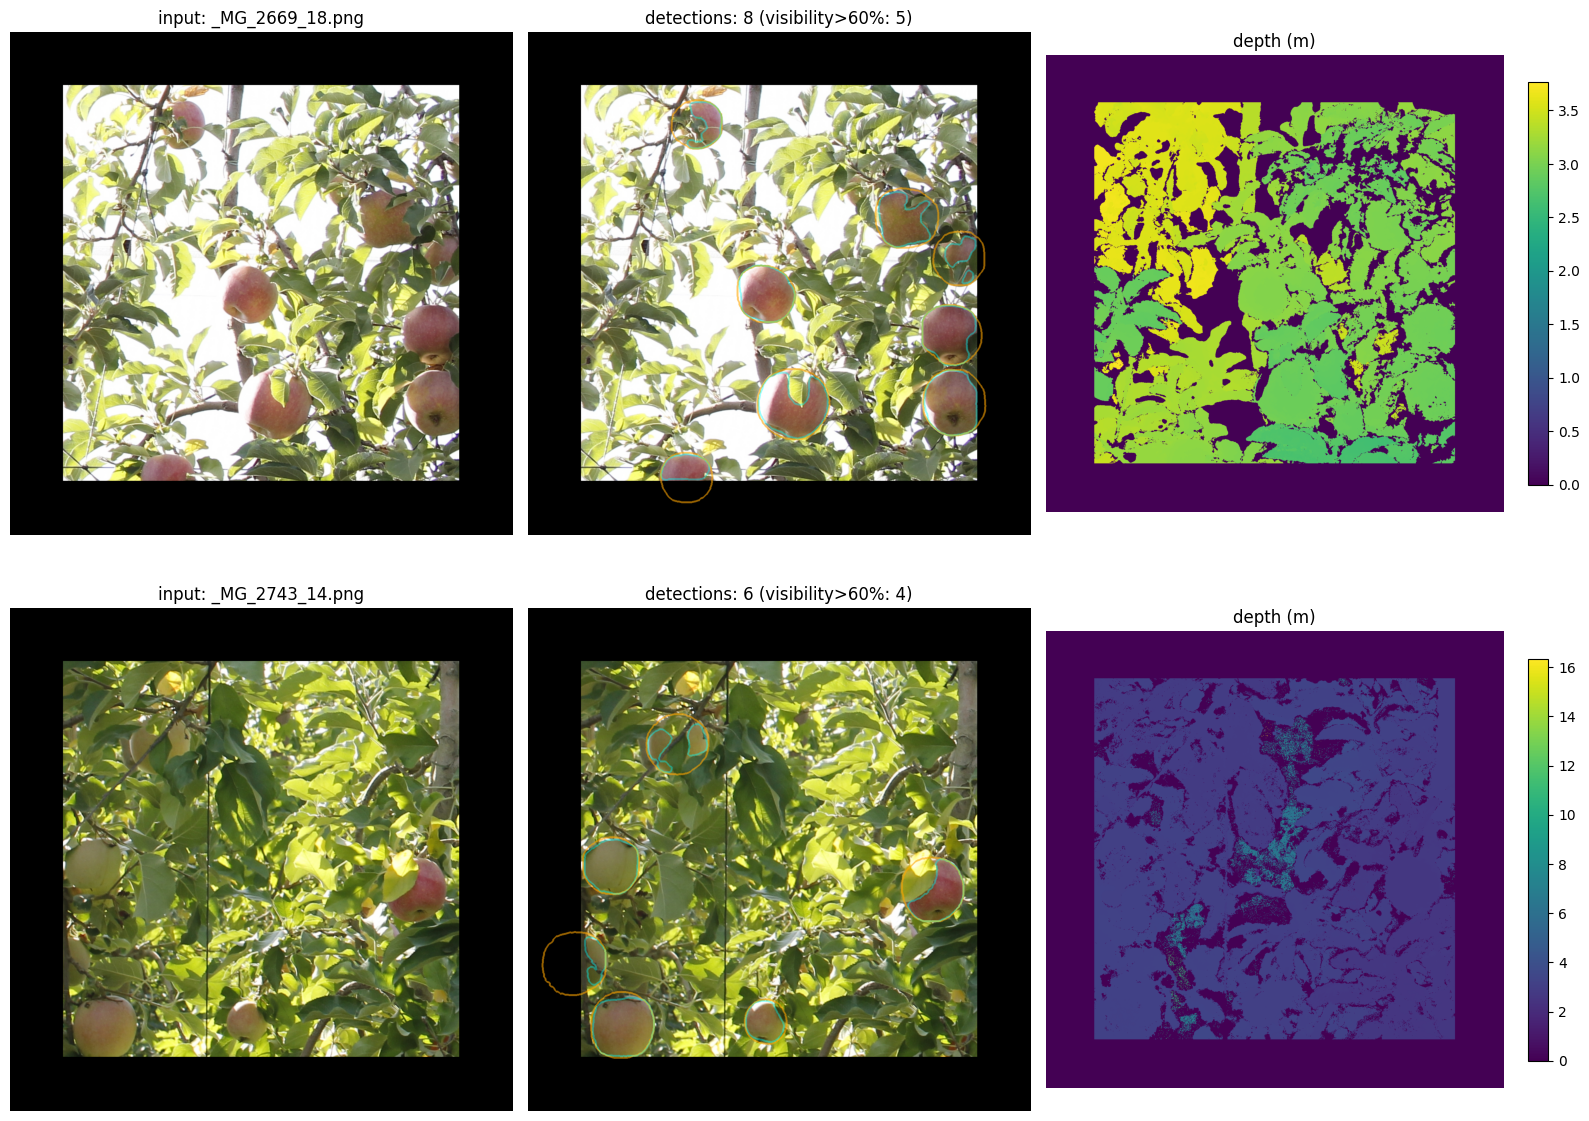

In [ ]:
fig, axes = plt.subplots(len(DEMO_IMAGES), 3, figsize=(16, 6 * len(DEMO_IMAGES)))
for row, name in enumerate(DEMO_IMAGES):
    preds = overlays[name]["preds"]
    vis_canvas = rgb[name].copy()
    amodal_canvas = rgb[name].copy()
    for j in range(len(preds)):
        vm = np.asarray(preds.pred_visible_masks[j]).astype(np.uint8)
        am = np.asarray(preds.pred_masks[j]).astype(np.uint8)   # amodal
        cv2.drawContours(vis_canvas, cv2.findContours(vm, cv2.RETR_TREE,
                         cv2.CHAIN_APPROX_SIMPLE)[0], -1, (255, 255, 0), 3)   # cyan in BGR
        cv2.drawContours(amodal_canvas, cv2.findContours(am, cv2.RETR_TREE,
                         cv2.CHAIN_APPROX_SIMPLE)[0], -1, (0, 165, 255), 3)   # orange in BGR
    blend = cv2.addWeighted(amodal_canvas, 0.6, vis_canvas, 0.4, 0)

    axes[row, 0].imshow(cv2.cvtColor(rgb[name], cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"input: {name}")
    axes[row, 1].imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB))
    n_vis = int((df[df.image == name].visibility_pct > 60).sum())
    axes[row, 1].set_title(f"detections: {len(preds)} (visibility>60%: {n_vis})")
    im = axes[row, 2].imshow(depth[name], cmap='viridis')
    axes[row, 2].set_title("depth (m)")
    plt.colorbar(im, ax=axes[row, 2], fraction=0.04)
    for ax in axes[row]: ax.axis('off')
plt.tight_layout(); plt.show()


## 8. Paper's visibility filter (>60%) and CSV export

The paper uses the automatically estimated visibility as a confidence value: restricting sizing to
apples with visibility > 60% improved MAE from 4.5 mm to 2.93 mm (test set, Fuji). Here we simply
mark which demo detections pass that filter (no ground truth is available for demo images).
Results are exported to `/content/amodal_apple_sizing_results.csv` inside the Colab VM.

**日本語**: 論文と同じ「可視率 > 60%」フィルタをデモ結果に適用し、結果表を CSV として
Colab 内(/content)に保存します。

In [ ]:
df["vis_gt_60"] = df.visibility_pct > 60.0
print("detections with visibility > 60% (paper's sizing condition):",
      int(df.vis_gt_60.sum()), "/", len(df))

OUT_CSV = '/content/amodal_apple_sizing_results.csv'
df.round(2).to_csv(OUT_CSV, index=False)
print("saved:", OUT_CSV, os.path.getsize(OUT_CSV), "bytes")
df.round(2)


detections with visibility > 60% (paper's sizing condition): 9 / 14
saved: /content/amodal_apple_sizing_results.csv 607 bytes


,image,apple_id,diameter_mm,visibility_pct,score,vis_gt_60
0,_MG_2669_18.png,0,84.68,84.74,1.00,True
1,_MG_2669_18.png,1,93.39,74.99,1.00,True
2,_MG_2669_18.png,2,79.55,94.83,1.00,True
3,_MG_2669_18.png,3,79.31,48.12,1.00,False
4,_MG_2669_18.png,4,71.87,48.50,1.00,False
5,_MG_2669_18.png,5,79.41,86.70,1.00,True
6,_MG_2669_18.png,6,84.04,66.31,1.00,True
7,_MG_2669_18.png,7,73.55,30.29,0.98,False
8,_MG_2743_14.png,0,92.13,90.49,1.00,True
9,_MG_2743_14.png,1,75.87,62.90,1.00,True


## 9. Interpretation, differences from the paper, validation record, references

**How to read the results.** Each row is one detected apple: `diameter_mm` from the pinhole model
(D = 2·√A·z/f), `visibility_pct` from the modal/amodal area ratio, `score` from the CNN.
Reasonable output: diameters in the tens of mm and moderate camera distances (depth ~1–5 m),
with amodal masks visibly extending behind leaves/branches. The depth maps come from photogrammetry
(SfM + MVS, Agisoft Metashape), which the paper itself lists as its main limitation (Sec. 4).

**Differences from the paper (scope).**
- Inference-only demo on 2 repository demo images with the released weights; the paper's numbers
  (F1 = 0.86; MAE = 4.5 mm → 2.93 mm at visibility > 60%; R² = 0.80 → 0.91) are dataset-level test-set
  results over 807 test images with calliper ground truth — **not** recomputed or verified here.
- The demo images have no ground-truth annotations, so no error metrics can be computed.
- Backbone: the released weights use the X-101-32x8d config (README); the paper text says ResNet-101.
  We follow the released weights.
- Software adaptation: the authors' 2022 environment (torch 1.12.1+cu113, Python 3.9) is replaced by
  the Colab-preinstalled PyTorch (torch 2.11.0+cpu, Python 3.13 at validation time); the fork is
  compiled from source with two behavior-preserving compatibility fixes (in-place build instead of
  `pip install -e .`, and `.type()` → `.scalar_type()` in five `AT_DISPATCH` calls). The scientific
  operations (config, predictor, diameter math, focal length, units) are the authors' own, called
  unchanged.

**Validation record.** Validated end-to-end in fresh Google Colab sessions on **both CPU and T4 GPU** (2026-09-27).
Measured: CPU — build ≈ 2.5 min, weights (877 MB) ≈ 2.7 min, inference ≈ 28 s, total ≈ 6 min;
T4 GPU — build (incl. CUDA kernels) ≈ 4.9 min, weights ≈ 68 s, inference ≈ 2 s, total ≈ 6.3 min.
The 14-detection table was identical between CPU and GPU up to float rounding (one visibility value
66.31 vs 66.32). Free-tier time/availability may differ. See `report.md` for details.

**References.**
- Paper: https://doi.org/10.1016/j.compag.2023.107854 (CC BY 4.0)
- Code: https://github.com/GRAP-UdL-AT/Amodal_Fruit_Sizing @ `628ddbf` (Apache-2.0; forks sizecnn/ORCNN/detectron2)
- Weights: https://zenodo.org/record/7144328/files/model_0002999.pth (record also CC BY 4.0)
- Dataset: https://zenodo.org/record/7260694 (CC BY 4.0)

**日本語**: このデモは著者公開の学習済みモデルをデモ画像 2 枚で実行する「部分的な再現」であり、
論文のデータセット全体の精度(F1, MAE, R²)の検証ではありません。デモ画像には正解注釈がないため、
誤差評価はできません。論文の可視率 > 60% フィルタと同じ条件の確認のみを行います。
